In [1]:
import numpy as np
import torch 
import denoising
import importlib
denoising = importlib.reload(denoising)
import utils
utils = importlib.reload(utils)
import  matplotlib.pyplot as plt


# import packages
import math
np.math = math  # Redirect numpy.math to the built-in math module

import glob

base_path_data = f"/Users/tsouros/Desktop/Results/"

test = np.load(base_path_data + 'example_fields.npy')

test = test[11][None, :, :]


def downsample(image):
    func = utils.downsample_by_four
    return func(image)

test2 = (np.sign(test[0]) * (np.abs(test[0]) ** 1.1))[None, :, :]

threshold_func = None
remove_edge = True

image_target = (test, test2)

_, M, N = test.shape

J = int(np.log2(min(M,N))) - 2

print(f'Starting...')
image_init = (np.random.normal(loc=0.0, scale=1.0, size=test.shape), np.random.normal(loc=0.0, scale=1.0, size=test.shape))

# image_init = (image_target[0] + image_init[0], image_target[1] + image_init[1])

running_map, loss = denoising.denoise(image_target, steps=50, image_init=image_init, remove_edge=remove_edge, precision='single', if_large_batch=False, mode='synthesis', J = J)

Starting...
Time used:  73.2055811882019 s


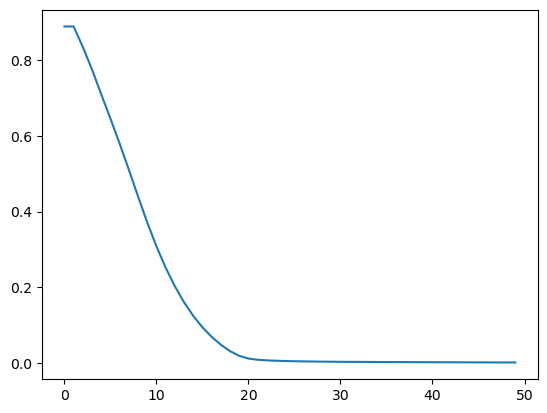

In [2]:
plt.plot(loss)

In [3]:
def margin_crop(image):
    H, W = image.shape[-2:]

    target_size = 128 + 128//2


    assert H == W, "Image must be square"
    assert target_size <= H, "Target size must be smaller than or equal to image size"

    margin = (H - target_size) // 2
    cropped = image[..., margin:margin + target_size, margin:margin + target_size]
    return cropped

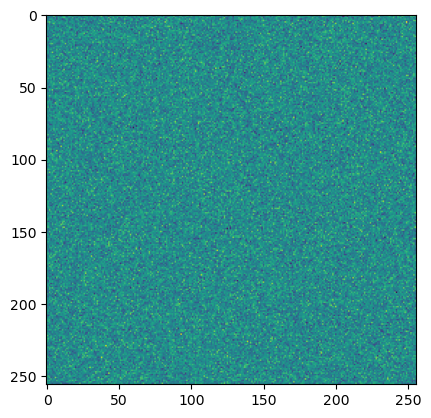

In [4]:
plt.imshow(image_init[0][0])

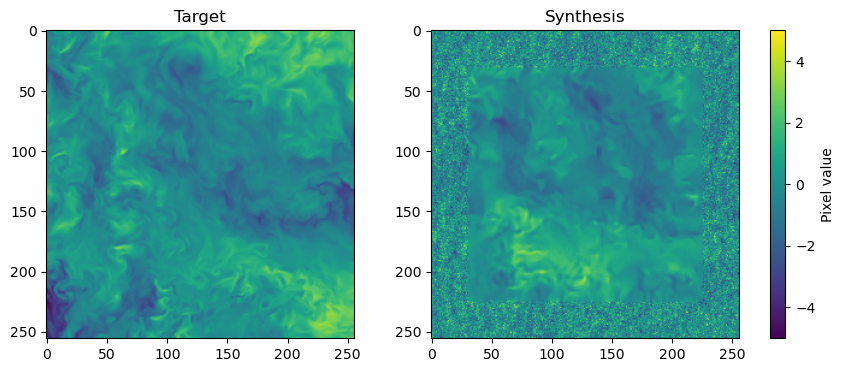

In [5]:
idx = 1
if True:
    im1 = image_target[idx][0]
    im2 = running_map[idx][0]
else:
    im1 = margin_crop(image_target[idx][0])
    im2 = margin_crop(running_map[idx][0])

# vmin = min(im1.min(), im2.min())
# vmax = max(im1.max(), im2.max())
vmin, vmax = -5, +5


fig, axs = plt.subplots(1, 2, figsize=(10, 4))

im0 = axs[0].imshow(im1, cmap='viridis', vmin=vmin, vmax=vmax)
axs[0].set_title("Target")

im1 = axs[1].imshow(im2, cmap='viridis', vmin=vmin, vmax=vmax)
axs[1].set_title("Synthesis")

cbar = fig.colorbar(im1, ax=axs, orientation='vertical', fraction=0.05, pad=0.04)
cbar.set_label("Pixel value")

plt.show()

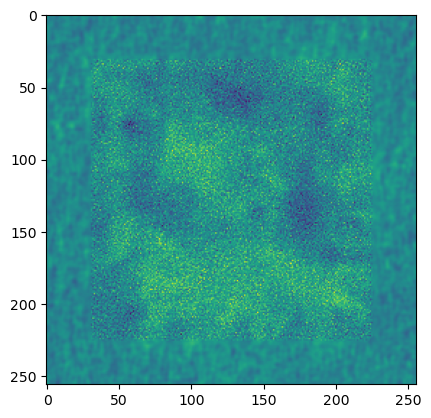

In [6]:
plt.imshow(running_map[0][0] - image_init[0][0])

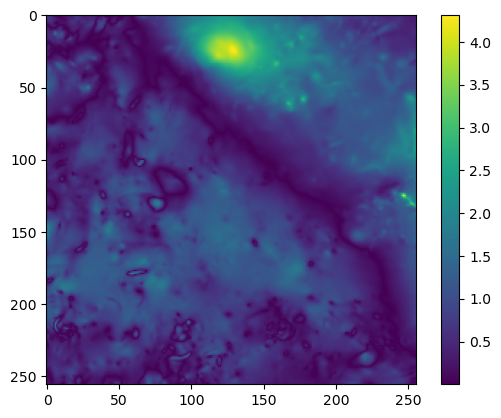

In [7]:
test = np.load(base_path_data + 'example_fields.npy')
test = np.abs(test[12])
plt.imshow(test)
plt.colorbar()